# MMYC 100 Miler – Course & Route Plotter

In [2]:
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy.interpolate import splprep, splev, griddata

from scipy.integrate import solve_bvp

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

In [111]:
# ── Race marks: (lon, lat) — NOTE: cartopy wants lon first ──────────────────
MARKS = {
    "Start/Finish\n(Menominee)": (-87.606, 45.111),
}

# Official course sequence (lon, lat)
OFFICIAL = [
    (-87.606, 45.111),
    (-87.560, 45.105),
    (-87.525, 45.055),
    (-87.490, 45.040),
    (-87.248, 45.145),
    (-87.245, 45.176),
    (-87.217, 45.177),
    (-87.210, 45.168),
    (-87.193, 45.177),
    (-87.195, 45.187),
    (-87.335, 45.260),
    (-87.606, 45.111) 
]

# ── Islands / obstacles: (lon, lat, label, radius_deg_approx) ───────────────
OBSTACLES = [
    (-87.357, 45.184, "Chambers Island", 0.055),
    (-87.265, 45.159, "Adventure Island", 0.010),
    (-87.210, 45.179, "Horseshoe\nIsland",    0.005),
    # (-87.268, 45.196, "Strawberry\nIslands",  0.018),
    (-87.497, 45.059, "Green Island",         0.013),
    # (-87.340, 45.215, "Hat Island",           0.008),
    # (-87.290, 45.175, "Nicolet Bay\nShoals",  0.015),
]

# ── Map extent: [lon_min, lon_max, lat_min, lat_max] ────────────────────────
EXTENT = [-87.80, -87.10, 44.88, 45.35]

In [4]:
def smooth_route(waypoints, n=400):
    """Fit a cubic spline through (lon, lat) waypoints."""
    lons = np.array([p[0] for p in waypoints])
    lats = np.array([p[1] for p in waypoints])
    k = min(3, len(waypoints) - 1)
    tck, _ = splprep([lons, lats], s=0, k=k)
    u = np.linspace(0, 1, n)
    lons_s, lats_s = splev(u, tck)
    return list(zip(lons_s, lats_s))

In [107]:
PLATE = ccrs.PlateCarree()


def add_basemap_features(ax):
    """Add land, water, and coastline features to a cartopy axis."""
    ax.add_feature(cfeature.OCEAN.with_scale('10m'),      facecolor='#c8ddf0', zorder=0)
    ax.add_feature(cfeature.LAND.with_scale('10m'),       facecolor='#e8e4d9', zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale('10m'),      facecolor='#c8ddf0', zorder=1)
    ax.add_feature(cfeature.RIVERS.with_scale('10m'),     edgecolor='#a0bcd0', linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'),  edgecolor='#6a8fa8', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'),    edgecolor='#aaaaaa', linewidth=0.5, linestyle=':', zorder=3)
    ax.add_feature(cfeature.STATES.with_scale('10m'),     edgecolor='#bbbbbb', linewidth=0.4, linestyle='--', zorder=3)


def draw_course(ax, waypoints, color='#222222', lw=1.6,
                linestyle='--', label='Official course', zorder=5):
    lons = [p[0] for p in waypoints]
    lats = [p[1] for p in waypoints]
    ax.plot(lons, lats, linestyle=linestyle, color=color,
            linewidth=lw, transform=PLATE, zorder=zorder, label=label)


def draw_route(ax, route, color, label, lw=2.2, zorder=6):
    lons = [p[0] for p in route]
    lats = [p[1] for p in route]
    ax.plot(lons, lats, color=color, linewidth=lw,
            transform=PLATE, zorder=zorder, label=label, alpha=0.88)
    # Direction arrow at ~60% along the route
    mid = int(len(route) * 0.6)
    ax.annotate('', xy=(lons[mid+3], lats[mid+3]),
                xytext=(lons[mid], lats[mid]),
                xycoords=PLATE._as_mpl_transform(ax),
                textcoords=PLATE._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8),
                zorder=zorder+1)


def draw_marks(ax, marks, zorder=10):
    for i, (name, (lon, lat)) in enumerate(marks.items(), start=1):
        is_start = i == 1
        color = '#111111' if is_start else '#cc2200'
        marker = 's' if is_start else 'o'
        ax.plot(lon, lat, marker=marker, color=color, markersize=9 if is_start else 8,
                markeredgecolor='white', markeredgewidth=1.2,
                transform=PLATE, zorder=zorder)
        # Number badge
        # ax.text(lon, lat, str(i), color='white', fontsize=5.5, fontweight='bold',
        #         ha='center', va='center', transform=PLATE, zorder=zorder+1)
        # Label — nudge to avoid overlap
        nudge = {1: (0.010, 0.006), 2: (-0.015, -0.012),
                 3: (0.010, 0.006), 4: (0.012, -0.005),
                 5: (0.012, 0.005), 6: (-0.005, 0.010)}
        dx, dy = nudge.get(i, (0.008, 0.006))
        ax.text(lon + dx, lat + dy, name,
                fontsize=6.5, color='#111111', transform=PLATE,
                zorder=zorder+1, ha='left',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])


def draw_obstacles(ax, obstacles, zorder=4):
    for lon, lat, label, r in obstacles:
        # Filled circle for island body
        circ = mpatches.Ellipse((lon, lat), width=r*1.4, height=r,
                                 facecolor='#c8b89a', edgecolor='#8a6a40',
                                 linewidth=1.0, transform=PLATE, zorder=zorder,
                                 alpha=0.85)
        ax.add_patch(circ)
        # Dashed exclusion ring
        ring = mpatches.Ellipse((lon, lat), width=(r+0.008)*1.4, height=r+0.008,
                                 facecolor='none', edgecolor='#e6550d',
                                 linewidth=0.8, linestyle=':', transform=PLATE,
                                 zorder=zorder+1, alpha=0.7)
        ax.add_patch(ring)
        ax.text(lon, lat - 0.6 * r - 0.01, label, fontsize=5.5,
                color='#7f2704', ha='center', transform=PLATE, zorder=zorder+2,
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])


def add_legend(ax, extra_handles=None):
    handles = [
        Line2D([0],[0], color='#222', lw=1.6, linestyle='--', label='Official course'),
        mpatches.Patch(facecolor='#c8b89a', edgecolor='#8a6a40', label='Island / shoal'),
        mpatches.Patch(facecolor='none', edgecolor='#e6550d',
                       linestyle=':', label='Exclusion zone'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#cc2200',
               markeredgecolor='white', markersize=8, label='Race mark'),
        Line2D([0],[0], marker='s', color='w', markerfacecolor='#111',
               markeredgecolor='white', markersize=8, label='Start / Finish'),
    ]
    if extra_handles:
        handles += extra_handles
    ax.legend(handles=handles, loc='lower right', fontsize=6.5,
              framealpha=0.92, edgecolor='#cccccc', fancybox=False)


def add_scalebar(ax, lon0, lat0, length_nm=10):
    """Rough scale bar — 1 nm ≈ 1/60 degree latitude."""
    deg = length_nm / 60.0
    ax.plot([lon0, lon0 + deg], [lat0, lat0], 'k-', lw=3, transform=PLATE, zorder=20)
    ax.text(lon0 + deg/2, lat0 + 0.004, f'{length_nm} nm',
            ha='center', fontsize=6, transform=PLATE, zorder=20)

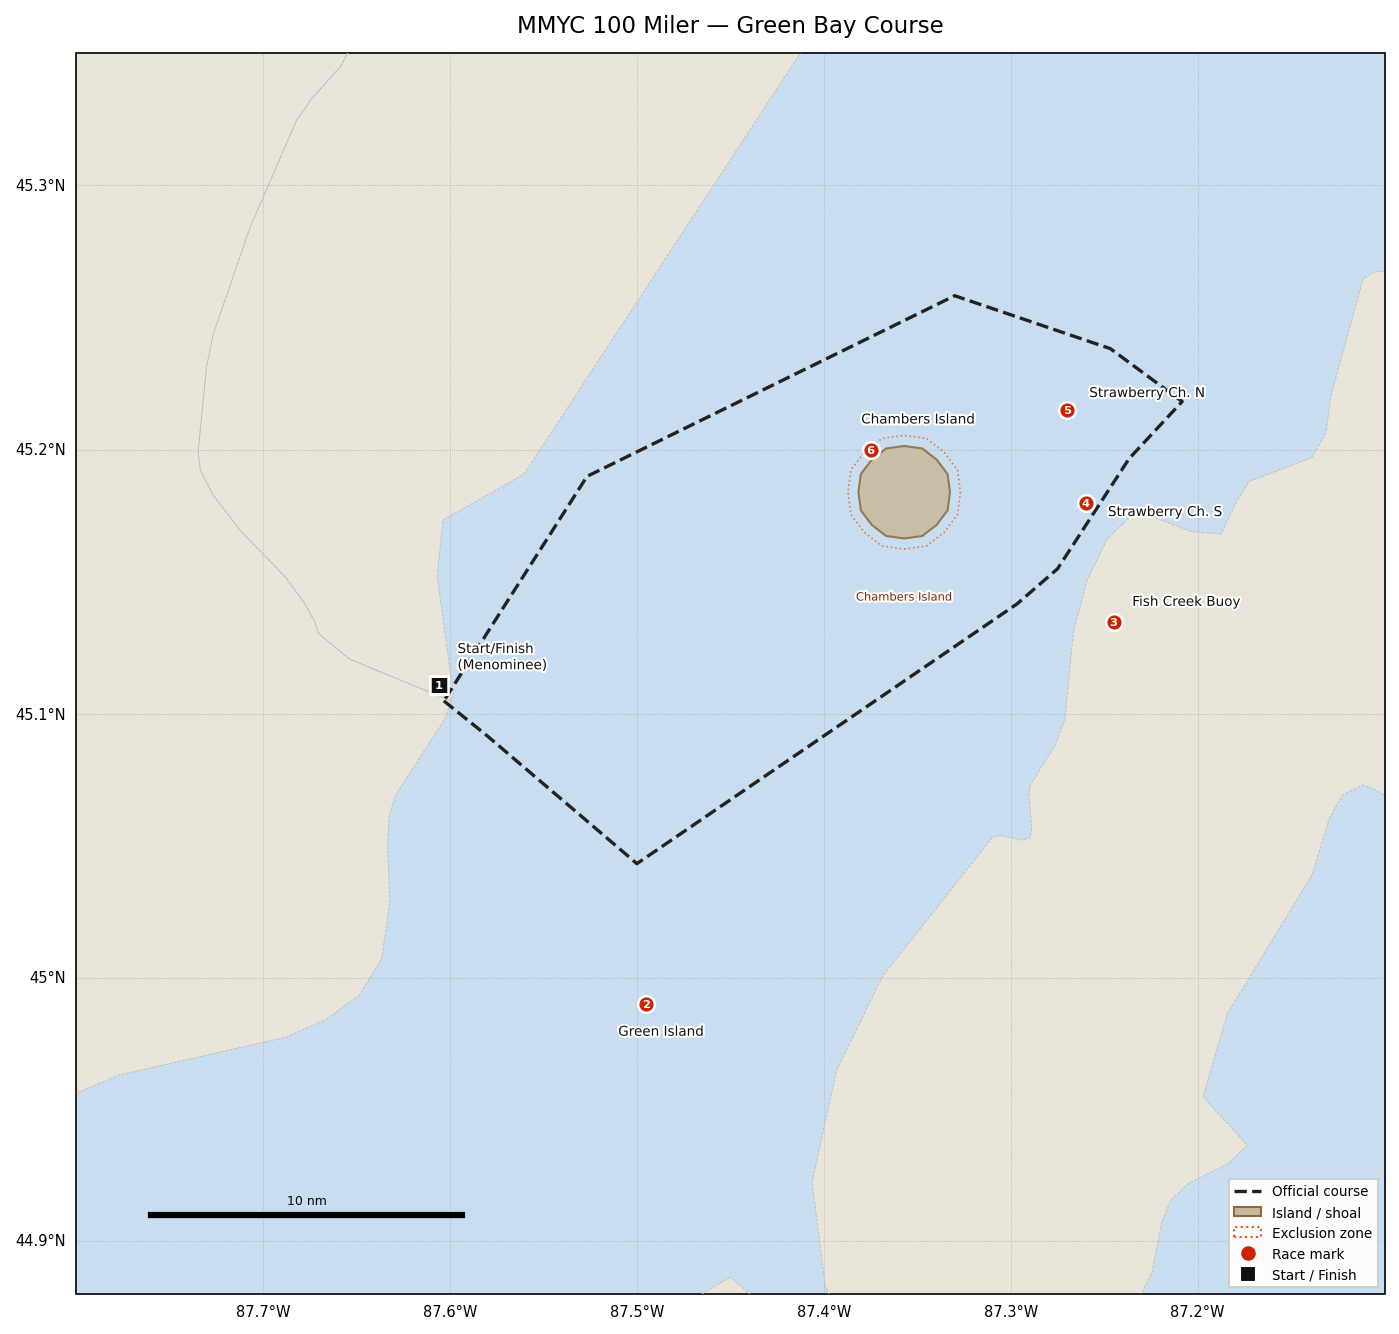

In [18]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())

ax.set_extent(EXTENT, crs=PLATE)
add_basemap_features(ax)

draw_obstacles(ax, OBSTACLES)
draw_course(ax, OFFICIAL, label='Official course')
draw_marks(ax, MARKS)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='#aaaaaa',
                  linestyle=':', x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7}
gl.ylabel_style = {'size': 7}

add_scalebar(ax, -87.76, 44.91, length_nm=10)
add_legend(ax)

ax.set_title('MMYC 100 Miler — Green Bay Course', fontsize=11, pad=10)

plt.tight_layout()
# plt.savefig('mmyc_100_miler_full.png', dpi=200, bbox_inches='tight')
plt.show()

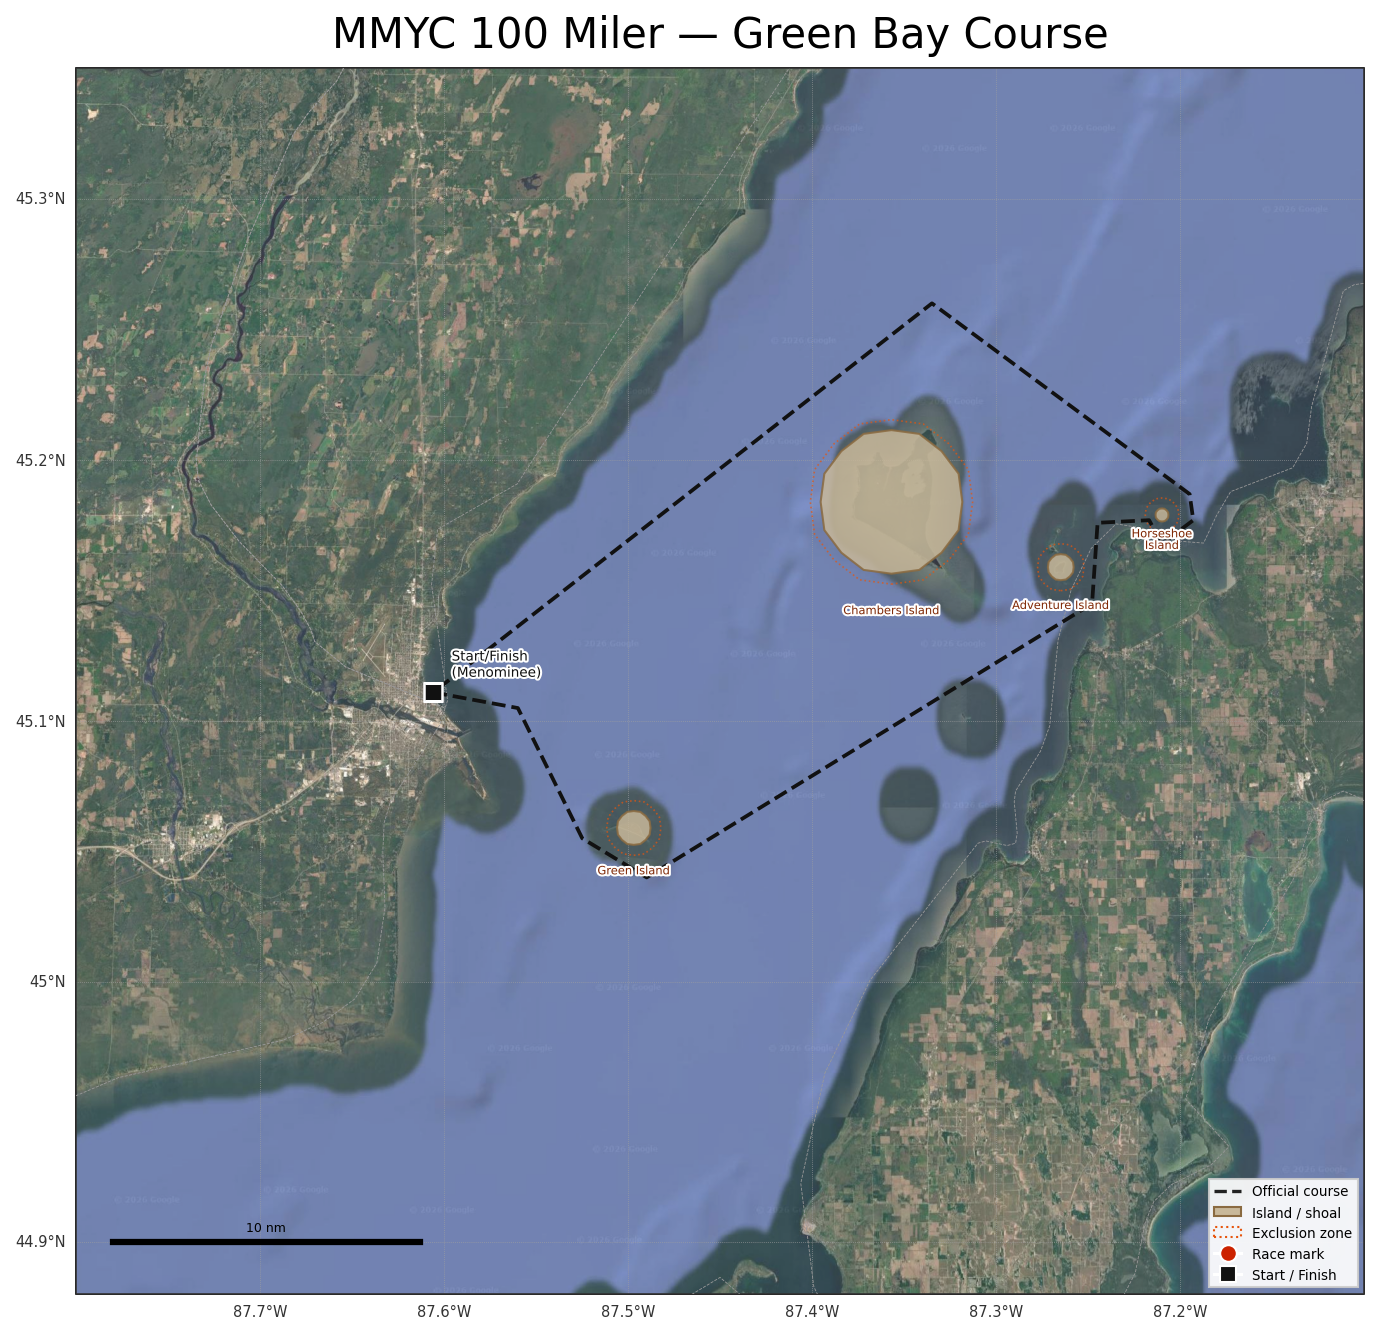

Saved → mmyc_100_miler_satellite_light.png


In [121]:
# ── Tuneable parameters ───────────────────────────────────────────────────────
ZOOM      = 12     # tile zoom: 10=fast, 11=balanced, 12=sharp/slow
SAT_ALPHA = 0.8   # satellite bleed-through on land (0=white, 1=full sat)

# ── Tile source ───────────────────────────────────────────────────────────────
sat_tiler = cimgt.GoogleTiles(style='satellite')

fig = plt.figure(figsize=(11, 9))
fig.patch.set_facecolor('white')
ax = fig.add_subplot(1, 1, 1, projection=sat_tiler.crs)
ax.set_extent(EXTENT, crs=PLATE)

# Layer 1 — white base so any tile gaps read white, not grey
ax.set_facecolor('white')

# Layer 2 — satellite tiles at a slightly reduced global alpha
# (cartopy doesn't accept alpha on add_image, so we set it on the artist after)
ax.add_image(sat_tiler, ZOOM)
for artist in ax.get_images():
    artist.set_alpha(0.6)

# Layer 3 — semi-transparent white wash over LAND only
# Water is left untouched so the bay reads as vivid blue-green.
# SAT_ALPHA controls how much satellite bleeds through:
#   lower SAT_ALPHA → thicker white → more muted land
ax.add_feature(
    cfeature.LAND.with_scale('10m'),
    facecolor='white',
    alpha=1.0 - SAT_ALPHA,
    zorder=3,
    edgecolor='none',
)

# Layer 4 — crisp coastline and state border on top of the wash
ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    edgecolor='#444444', linewidth=0.75, zorder=4,
)
ax.add_feature(
    cfeature.STATES.with_scale('10m'),
    edgecolor='#999999', linewidth=0.4, linestyle='--',
    facecolor='none', zorder=4,
)

# Layer 5 — course, routes, marks
# Use dark, saturated colours — they read well on the light land
# and pop against the vivid water.
draw_obstacles(ax, OBSTACLES, zorder=5)
draw_course(ax, OFFICIAL, color='#111111', lw=1.8, label='Official course', zorder=6)
draw_marks(ax, MARKS, zorder=10)

# Gridlines — dark labels for light background
gl = ax.gridlines(draw_labels=True, linewidth=0.35, color='#888888',
                  linestyle=':', x_inline=False, y_inline=False)
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': '#333333'}
gl.ylabel_style = {'size': 7, 'color': '#333333'}

add_scalebar(ax, EXTENT[0] + 0.02, EXTENT[2] + 0.02, length_nm=10)
add_legend(ax)
ax.set_title('MMYC 100 Miler — Green Bay Course',
             fontsize=20, pad=10, color="#000000")

plt.tight_layout()
plt.savefig('poster/route_map.png', dpi=200,
            bbox_inches='tight', facecolor='#DBD6D1', edgecolor='none')
plt.show()
print('Saved → mmyc_100_miler_satellite_light.png')

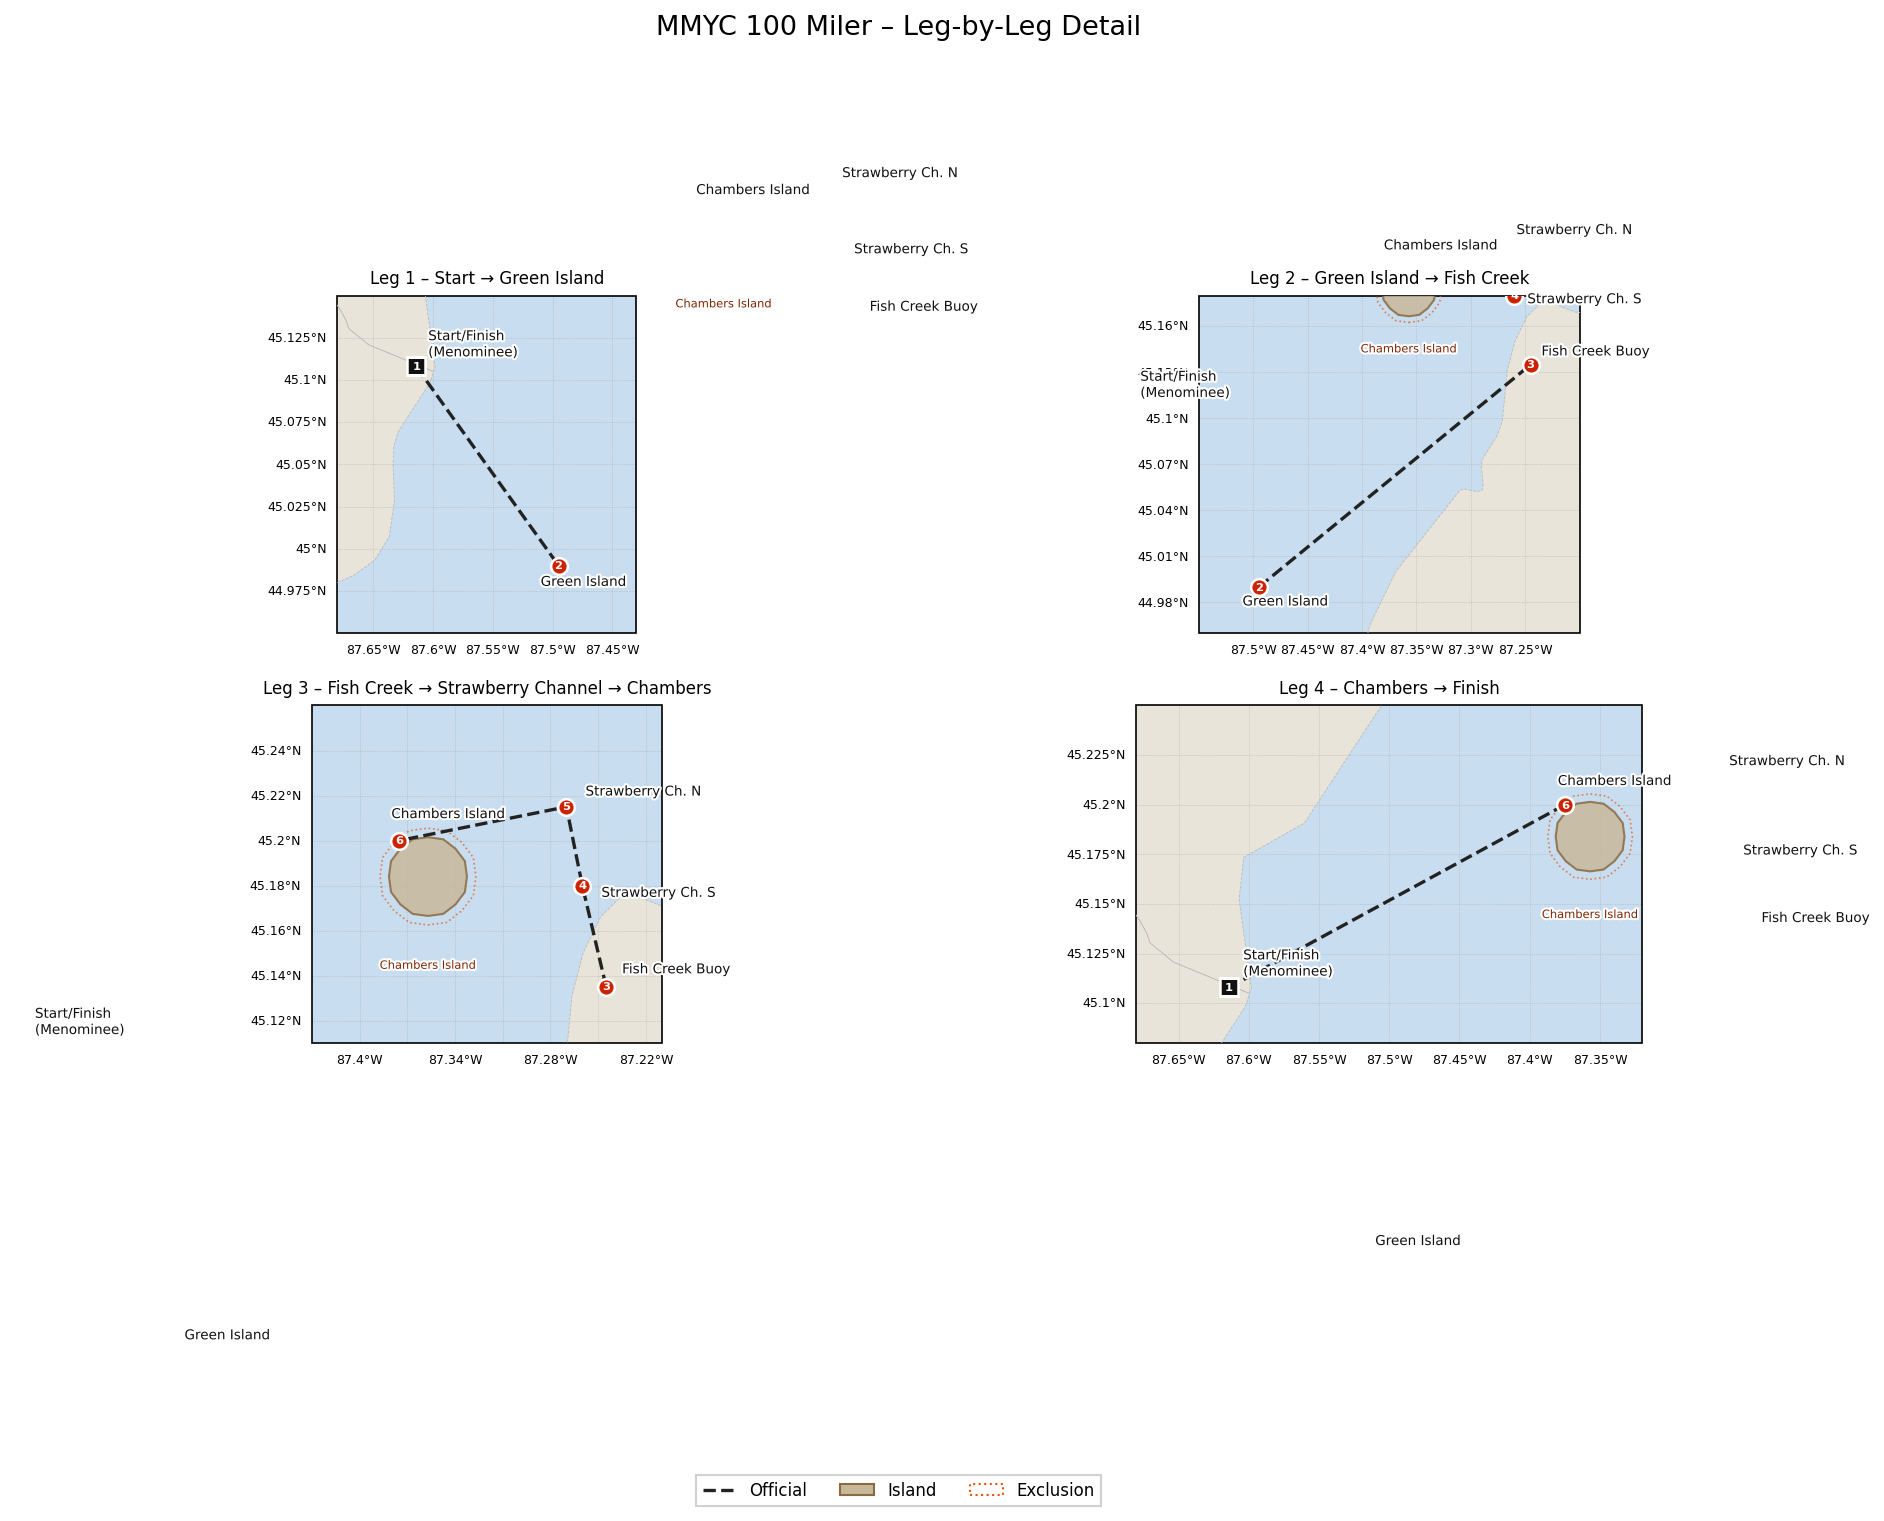

In [39]:
LEGS = [
    ("Leg 1 – Start → Green Island",
     [-87.68, -87.43, 44.95, 45.15],
     0, 2),
    ("Leg 2 – Green Island → Fish Creek",
     [-87.55, -87.20, 44.96, 45.18],
     1, 3),
    ("Leg 3 – Fish Creek → Strawberry Channel → Chambers",
     [-87.43, -87.21, 45.11, 45.26],
     2, 6),
    ("Leg 4 – Chambers → Finish",
     [-87.68, -87.32, 45.08, 45.25],
     5, 7),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                          subplot_kw={'projection': ccrs.Mercator()})

for ax, (title, extent, i_start, i_end) in zip(axes.flat, LEGS):
    ax.set_extent(extent, crs=PLATE)
    add_basemap_features(ax)
    draw_obstacles(ax, OBSTACLES)

    # Slice official course to this leg
    leg_pts = OFFICIAL[i_start : min(i_end, len(OFFICIAL))]
    if leg_pts:
        draw_course(ax, leg_pts, label='Official')

    # Full routes (clipped to extent by matplotlib automatically)
    draw_marks(ax, MARKS)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='#aaaaaa',
                      linestyle=':', x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 6}
    gl.ylabel_style = {'size': 6}
    ax.set_title(title, fontsize=8, pad=6)

# Shared legend on the figure
handles = [
    Line2D([0],[0], color='#222', lw=1.6, linestyle='--', label='Official'),
    mpatches.Patch(facecolor='#c8b89a', edgecolor='#8a6a40', label='Island'),
    mpatches.Patch(facecolor='none', edgecolor='#e6550d', linestyle=':', label='Exclusion'),
]
fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=8, framealpha=0.9, fancybox=False,
           bbox_to_anchor=(0.5, 0.01))

fig.suptitle('MMYC 100 Miler – Leg-by-Leg Detail', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig('mmyc_100_miler_legs.png', dpi=200, bbox_inches='tight')

In [40]:
# ── Replace these with output from your OCP solver ──────────────────────────
my_optimal_route_waypoints = [
    (-87.614, 45.108),
    (-87.614, 45.108),
]

if len(my_optimal_route_waypoints) > 3:
    my_route = smooth_route(my_optimal_route_waypoints)

    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
    ax.set_extent(EXTENT, crs=PLATE)
    add_basemap_features(ax)
    draw_obstacles(ax, OBSTACLES)
    draw_course(ax, OFFICIAL)
    draw_route(ax, route_a, '#2171b5', 'Route A')
    draw_route(ax, route_b, '#d73027', 'Route B')
    draw_route(ax, my_route, '#2ca25f', 'My optimal route', lw=3.0)
    draw_marks(ax, MARKS)
    add_legend(ax, extra_handles=[
        Line2D([0],[0], color='#2ca25f', lw=3, label='My optimal route')
    ])
    ax.set_title('MMYC 100 Miler — With Optimal Control Solution', fontsize=11)
    plt.tight_layout()
    plt.savefig('mmyc_optimal.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("Add your solver waypoints to my_optimal_route_waypoints above.")

Add your solver waypoints to my_optimal_route_waypoints above.


In [9]:
def met_to_uv(speed, direction_deg):
    """
    Convert meteorological direction (degrees FROM, 0=N clockwise)
    to u/v vector components for matplotlib quiver / barbs.

    Met convention: wind FROM 270° (west) → blows EAST → u>0, v=0.
    Cartopy quiver points in the direction the wind is GOING, so we
    negate: u = -sin(dir), v = -cos(dir).
    """
    rad = np.deg2rad(direction_deg)
    u = -speed * np.sin(rad)
    v = -speed * np.cos(rad)
    return u, v


def _pivot_grid(df, value_col):
    """
    Pivot a flat DataFrame (lat, lon, value) onto a 2-D meshgrid
    using scipy griddata for irregular grids, or direct reshape
    if the grid is already regular.
    Returns (lon2d, lat2d, val2d) — all 2-D arrays.
    """
    lons_u = np.sort(df['lon'].unique())
    lats_u = np.sort(df['lat'].unique())
    lon2d, lat2d = np.meshgrid(lons_u, lats_u)

    # Try direct pivot first (fast, works when grid is perfectly regular)
    try:
        pivot = df.pivot(index='lat', columns='lon', values=value_col)
        val2d = pivot.reindex(index=lats_u, columns=lons_u).values
        if np.isnan(val2d).mean() > 0.3:   # too many holes → fall back
            raise ValueError
    except Exception:
        val2d = griddata(
            (df['lon'].values, df['lat'].values),
            df[value_col].values,
            (lon2d, lat2d),
            method='linear'
        )
    return lon2d, lat2d, val2d


def _make_ax(extent=EXTENT):
    """Convenience: create a fresh cartopy Mercator axis with basemap."""
    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
    ax.set_extent(extent, crs=PLATE)
    add_basemap_features(ax)
    return fig, ax

Saved → combined_conditions.png


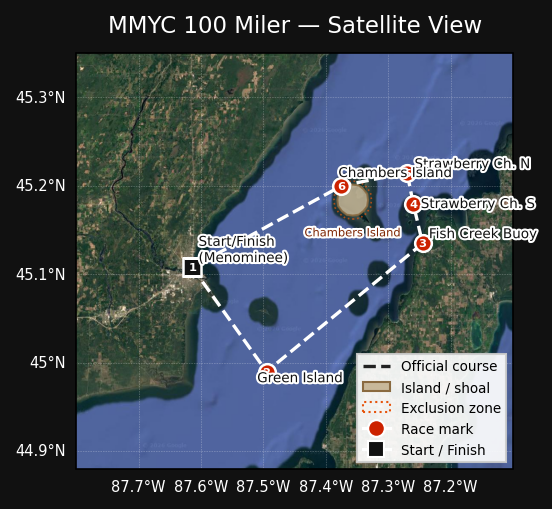

(<Figure size 1650x1350 with 2 Axes>,
 <GeoAxes: title={'center': 'MMYC 100 Miler — Wind & Wave Conditions'}>)

In [59]:
def plot_combined(
    df,
    course=True,
    routes=True,
    barb_stride=2,
    wave_stride=3,
    wind_cmap='YlOrRd',
    wind_alpha=0.55,
    units_label='Wind speed (m/s)',
    title='MMYC 100 Miler — Wind & Wave Conditions',
    extent=EXTENT,
    save_path='combined_conditions.png',
):
    """
    All-in-one overlay:
      • Wind speed color fill (contourf)
      • Wind barbs
      • Wave direction quiver arrows (colored by Tp via colormap)
      • Official course + proposed routes + marks + obstacles

    Parameters
    ----------
    df           : DataFrame with all five columns
    course       : overlay the official course line
    routes       : overlay route_a and route_b
    barb_stride  : thin wind barbs (1 = every point)
    wave_stride  : thin wave arrows (use larger than barb_stride for clarity)
    wind_alpha   : transparency of wind fill (lower to see land features better)
    """
    fig, ax = _make_ax(extent)

    # Layer 1 — wind speed fill
    # plot_wind_contour(df, ax=ax, cmap=wind_cmap, alpha=wind_alpha,
    #                   draw_contour_lines=False, units_label=units_label)

    # Layer 2 — wind barbs
    plot_wind_barbs(df, ax=ax, stride=barb_stride, units='m/s',
                    color='#1a1a2e', length=5)

# gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='#ffffff88',
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="#FFFFFF88",
                  linestyle=':', x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'white'}
gl.ylabel_style = {'size': 7, 'color': 'white'}

    ax.quiver(
        df_s['lon'].values, df_s['lat'].values, u, v,
        transform=PLATE,
        color=wave_colors,
        scale=80, scale_units='width',
        width=0.0035, headwidth=3.5, headlength=3.5,
        alpha=0.9, zorder=9,
    )

    # Wave Tp colorbar (secondary)
    sm = ScalarMappable(cmap='Blues', norm=tp_norm)
    sm.set_array([])
    cbar2 = fig.colorbar(sm, ax=ax, orientation='vertical',
                         pad=0.08, shrink=0.75, aspect=25)
    cbar2.set_label('Wave Tp (s)', fontsize=8)
    cbar2.ax.tick_params(labelsize=7)

    # Layer 4 — race course & routes
    draw_obstacles(ax, OBSTACLES)
    if course:
        draw_course(ax, OFFICIAL, color='white', lw=2.0)
    # if routes:
    #     draw_route(ax, route_a, '#00e5ff', 'Route A', lw=2.2)
    #     draw_route(ax, route_b, '#ff6e40', 'Route B', lw=2.2)
    draw_marks(ax, MARKS)

    _add_grid(ax)
    add_scalebar(ax, extent[0]+0.02, extent[2]+0.02, length_nm=10)

    # Legend
    handles = [
        Line2D([0],[0], color='white',   lw=2, linestyle='--', label='Official course'),
        Line2D([0],[0], color='#00e5ff', lw=2.2, label='Route A – port-tack'),
        Line2D([0],[0], color='#ff6e40', lw=2.2, label='Route B – offshore'),
        Line2D([0],[0], color='#1a1a2e', lw=1, marker=r'o',
               markersize=8, label='Wind barbs'),
        Line2D([0],[0], marker=r'$\rightarrow$', color='#2171b5',
               markersize=10, lw=0, label='Wave direction (scaled by Tp)'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=6.5,
              framealpha=0.88, edgecolor='#555', fancybox=False,
              facecolor='#111111', labelcolor='white')

    ax.set_title(title, fontsize=11, pad=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    return fig, ax

df = pd.read_csv("data/green_bay_wind_snapshot.csv")

# ── Run with demo data — swap df_demo for your real DataFrame ────────────────
plot_combined(
    df,
    barb_stride=2,
    wave_stride=3,
)

In [15]:
df

,time,lat,lon,waveTp,windDirection,waveHs,windSpeed,waveMeanDirection,station_id
0,2024-07-27 12:00:00,45.24,-87.20,2.398438,214.0,0.273438,5.203125,220.0,ST94144
1,2024-07-27 12:00:00,45.24,-87.24,2.390625,214.0,0.250000,5.101562,217.0,ST94145
2,2024-07-27 12:00:00,45.24,-87.28,2.398438,214.0,0.242188,4.898438,213.0,ST94146
3,2024-07-27 12:00:00,45.20,-87.28,2.578125,213.0,0.218750,4.898438,210.0,ST94147
4,2024-07-27 12:00:00,45.16,-87.28,2.640625,213.0,0.257812,4.796875,217.0,ST94148
5,2024-07-27 12:00:00,45.12,-87.32,2.679688,213.0,0.281250,4.796875,221.0,ST94149
6,2024-07-27 12:00:00,45.08,-87.32,2.656250,213.0,0.273438,4.796875,225.0,ST94150
7,2024-07-27 12:00:00,45.08,-87.36,2.671875,213.0,0.281250,4.796875,222.0,ST94151
8,2024-07-27 12:00:00,45.08,-87.40,2.679688,212.0,0.289062,4.796875,217.0,ST94152
9,2024-07-27 12:00:00,45.04,-87.40,2.671875,212.0,0.289062,4.898438,221.0,ST94153
